In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import median_abs_deviation

In [2]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [5]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

In [6]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

In [7]:
df_bioimpedance['TFC Dif'] = df_bioimpedance['Weight']/100*df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] - df_bioimpedance['Total Fat Content (TFC)']
df_bioimpedance['Lean-Fat Dif'] =df_bioimpedance['Weight'] - df_bioimpedance['Weight']/100*df_bioimpedance['Lean Mass (LM) (%)'] - df_bioimpedance['Total Fat Content (TFC)']
df_bioimpedance['Total mass percentage Dif'] = (
    df_bioimpedance['Lean Mass (LM) (%)']
    + df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
    - 100
)
df_bioimpedance

,Weight,Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),TFC Dif,Lean-Fat Dif,Total mass percentage Dif
0,92.8,52.9,21.2,31.7,40.00,19.20,80.84,18.88,9,3.7,71.4,23.40,17.8,10.60,39.7,0.01760,-0.01952,0.04
1,94.5,43.1,19.5,23.6,45.00,32.80,67.20,16.68,15,3.2,60.3,38.80,31.0,18.40,32.7,-0.00400,-0.00400,0.00
2,91.1,47.2,20.1,27.1,43.00,27.30,72.67,16.35,15,3.3,62.9,41.70,24.9,16.20,34.0,-0.02970,-0.00237,-0.03
3,67.7,41.4,17.0,24.4,41.00,15.80,84.19,16.90,6,2.9,54.1,9.00,10.7,6.50,29.2,-0.00340,0.00337,-0.01
4,89.6,51.4,20.0,31.4,39.00,20.00,80.02,16.81,8,3.5,68.2,28.60,17.9,10.40,37.4,0.02000,0.00208,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,88.8,47.6,20.0,28.0,42.01,24.66,75.23,16.13,11,3.3,63.5,14.39,21.9,13.58,34.2,-0.00192,0.09576,-0.11
315,53.4,29.3,12.3,17.0,42.00,23.60,76.40,15.96,2,2.1,38.7,1.50,12.6,5.10,22.2,0.00240,0.00240,0.00
316,96.6,49.2,21.0,28.2,43.00,28.80,71.22,15.87,16,3.4,65.4,48.40,27.8,17.10,35.6,0.02080,0.00148,0.02
317,88.4,50.2,19.9,30.3,40.00,21.10,78.85,16.30,8,3.4,66.3,28.30,18.7,11.00,36.1,-0.04760,-0.00340,-0.05


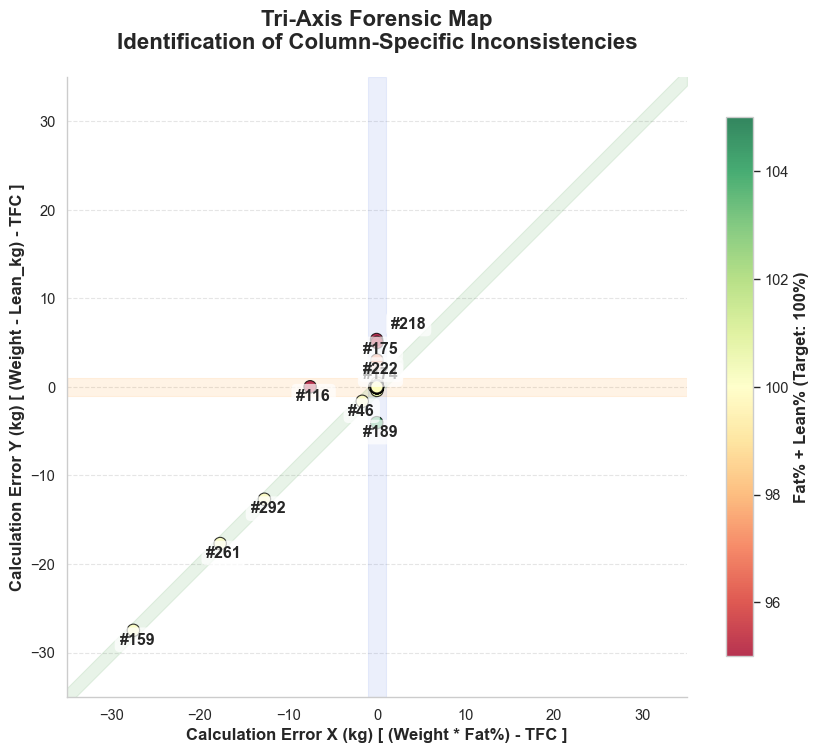

In [8]:
# ==============================================================================
# FIGURE: Tri-Axis Forensic Map (Automated Inconsistency Diagnosis)
# ==============================================================================

# 1. 计算三轴残差
df_bioimpedance['X_Res'] = (df_bioimpedance['Weight'] / 100 * df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']) - df_bioimpedance['Total Fat Content (TFC)']
df_bioimpedance['Y_Res'] = df_bioimpedance['Weight'] - (df_bioimpedance['Weight'] / 100 * df_bioimpedance['Lean Mass (LM) (%)']) - df_bioimpedance['Total Fat Content (TFC)']
df_bioimpedance['Pct_Sum'] = df_bioimpedance['Lean Mass (LM) (%)'] + df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']

# 2. 自动化诊断逻辑 (容差范围: 1.0kg / 1.5%)
tol_kg, tol_pct = 1.0, 1.5
outlier_mask = (df_bioimpedance['X_Res'].abs() > tol_kg) | (df_bioimpedance['Y_Res'].abs() > tol_kg) | ((df_bioimpedance['Pct_Sum']-100).abs() > tol_pct)

# 3. 绘图执行
fig, ax = plt.subplots(figsize=(10, 10))
limit = 35
ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit); ax.set_aspect('equal')

# 绘制容差色带
ax.axvspan(-tol_kg, tol_kg, color='royalblue', alpha=0.1, label='TFC-Fat% Consistent')
ax.axhspan(-tol_kg, tol_kg, color='darkorange', alpha=0.1, label='TFC-Lean% Consistent')
x_vals = np.array([-limit, limit])
ax.fill_between(x_vals, x_vals - tol_kg, x_vals + tol_kg, color='forestgreen', alpha=0.1, label='Internal Logic Consistent')

# 数据散点与标注
scatter = ax.scatter(df_bioimpedance['X_Res'], df_bioimpedance['Y_Res'], c=df_bioimpedance['Pct_Sum'],
                     cmap='RdYlGn', s=80, edgecolors='black', alpha=0.8, vmin=95, vmax=105)

for idx, row in df_bioimpedance[outlier_mask].iterrows():
    ax.annotate(f"#{idx}", (row['X_Res'], row['Y_Res']), xytext=(10, 10) if row['X_Res'] >= 0 else (-10, -10),
                textcoords='offset points', fontweight='bold', bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='none'))

format_plot(ax, "Tri-Axis Forensic Map\nIdentification of Column-Specific Inconsistencies",
            "Calculation Error X (kg) [ (Weight * Fat%) - TFC ]",
            "Calculation Error Y (kg) [ (Weight - Lean_kg) - TFC ]")

plt.colorbar(scatter, shrink=0.7, label='Fat% + Lean% (Target: 100%)')
plt.show()

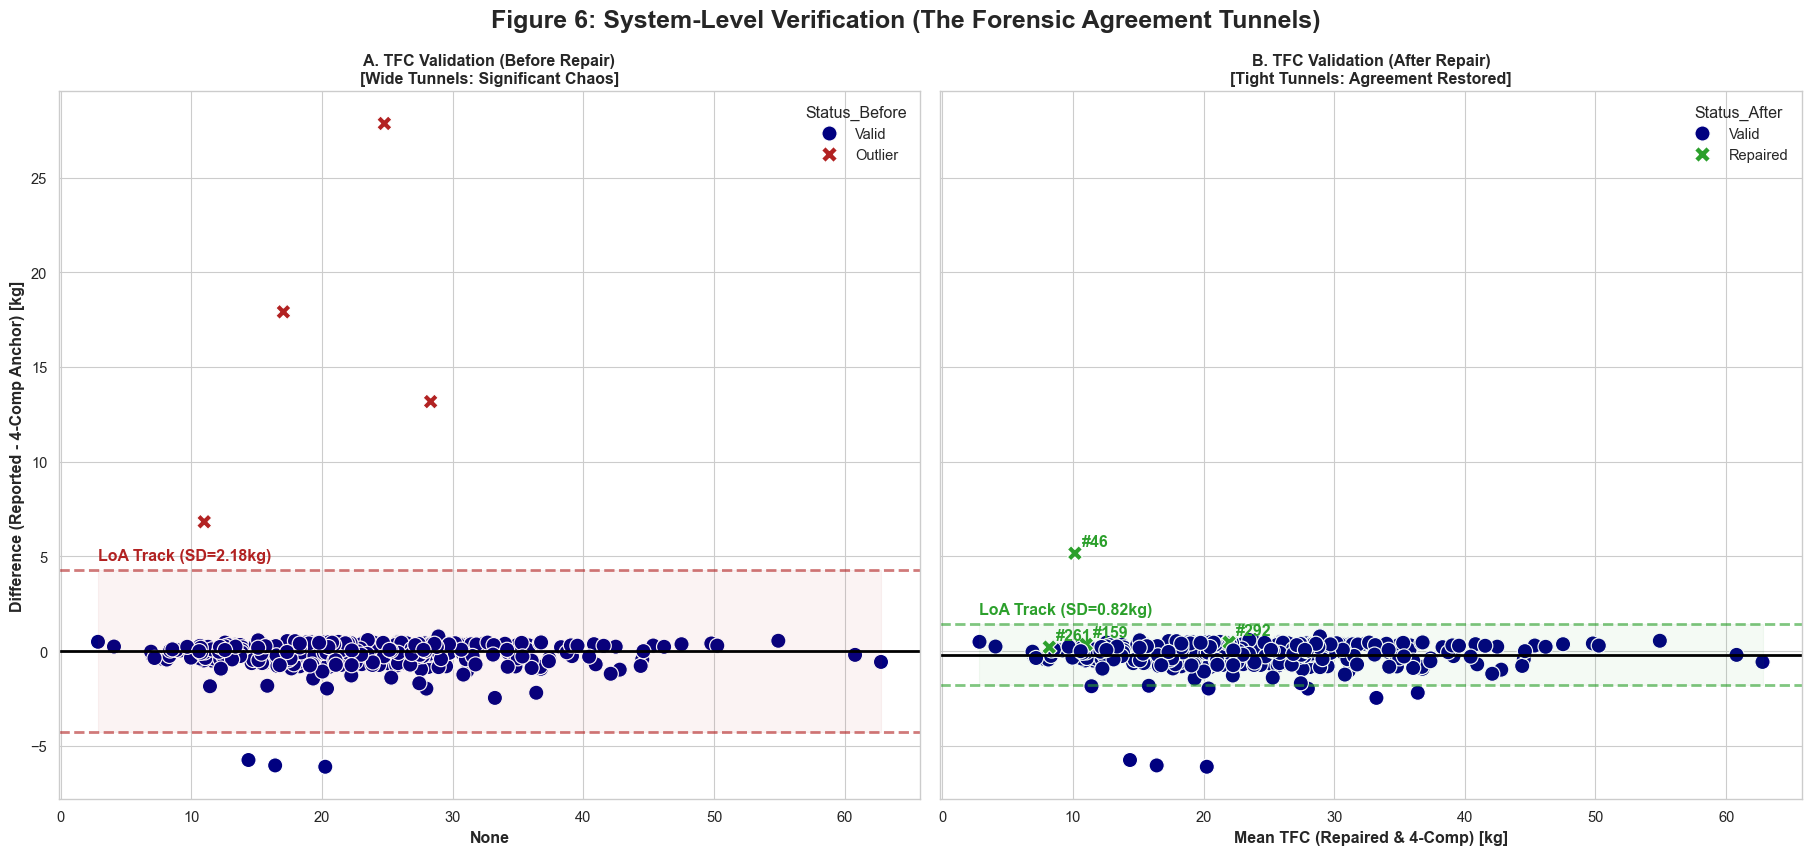

In [9]:

# --- 1. 数据准备与基础修复 ---
df_ba = df.copy()

# 修复 TBW (作为 TFC 验证的基准)
df_ba['Calc_Ratio_TBW'] = df_ba['Extracellular Water (ECW)'] / (df_ba['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)
df_ba['Res_TBW_Phys'] = df_ba['Total Body Water (TBW)'] - (df_ba['Extracellular Water (ECW)'] + df_ba['Intracellular Water (ICW)'])
df_ba['Res_TBW_Logi'] = df_ba['Total Body Water (TBW)'] - df_ba['Calc_Ratio_TBW']
mask_tbw_bad = (df_ba['Res_TBW_Phys'].abs() > 1.0) & (df_ba['Res_TBW_Logi'].abs() > 1.0)
df_ba['TBW_Fixed'] = df_ba['Total Body Water (TBW)']
df_ba.loc[mask_tbw_bad, 'TBW_Fixed'] = df_ba.loc[mask_tbw_bad, 'Calc_Ratio_TBW']

# 建立 4-Comp TFC 锚点
epsilon = 0.94
prot_kg = df_ba['Weight'] * (df_ba['Body Protein Content (Protein) (%)'] / 100)
df_ba['TFC_Anchor'] = df_ba['Weight'] - df_ba['TBW_Fixed'] - df_ba['Bone Mass (BM)'] - prot_kg - epsilon

# TFC 诊断轨道
df_ba['X_Res'] = (df_ba['Weight'] * df_ba['Total Body Fat Ratio (TBFR) (%)'] / 100) - df_ba['Total Fat Content (TFC)']
df_ba['Y_Res'] = (df_ba['Weight'] - (df_ba['Weight'] * df_ba['Lean Mass (LM) (%)'] / 100)) - df_ba['Total Fat Content (TFC)']
df_ba['Pct_Sum'] = df_ba['Total Body Fat Ratio (TBFR) (%)'] + df_ba['Lean Mass (LM) (%)']

# 执行 TFC 修复
mask_tfc_outlier = (abs(df_ba['Pct_Sum'] - 100) < 1.0) & (df_ba['X_Res'].abs() > 1.0)
df_ba['TFC_Final'] = df_ba['Total Fat Content (TFC)']
df_ba.loc[mask_tfc_outlier, 'TFC_Final'] = df_ba['Weight'] * (df_ba['Total Body Fat Ratio (TBFR) (%)'] / 100)

# 标记状态
df_ba['Status_Before'] = 'Valid'
df_ba.loc[mask_tfc_outlier, 'Status_Before'] = 'Outlier'
df_ba['Status_After'] = 'Valid'
df_ba.loc[mask_tfc_outlier, 'Status_After'] = 'Repaired'

# ==============================================================================
# FIGURE 6: THE TUNNEL OF TRUTH (Bland-Altman Comparison)
# ==============================================================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True, constrained_layout=True)

# 调色板
pal_before = {'Valid': 'navy', 'Outlier': 'firebrick'}
pal_after = {'Valid': 'navy', 'Repaired': 'tab:green'}

# --- A. Before Repair: The "Broken" Tunnels ---
ax1 = axes[0]
diff_before = df_ba['Total Fat Content (TFC)'] - df_ba['TFC_Anchor']
mean_before = (df_ba['Total Fat Content (TFC)'] + df_ba['TFC_Anchor']) / 2
sns.scatterplot(x=mean_before, y=diff_before, hue=df_ba['Status_Before'],
                palette=pal_before, style=df_ba['Status_Before'], markers={'Valid':'o','Outlier':'X'}, s=120, ax=ax1)

m1, s1 = diff_before.mean(), diff_before.std()
# 绘制你的“虚线轨道”
ax1.axhline(m1, color='black', lw=2)
ax1.axhline(m1 + 1.96*s1, color='firebrick', ls='--', lw=2, alpha=0.6) # 上轨道
ax1.axhline(m1 - 1.96*s1, color='firebrick', ls='--', lw=2, alpha=0.6) # 下轨道
ax1.fill_between([mean_before.min(), mean_before.max()], m1-1.96*s1, m1+1.96*s1, color='firebrick', alpha=0.05)

ax1.set_title("A. TFC Validation (Before Repair)\n[Wide Tunnels: Significant Chaos]", fontweight='bold')
ax1.set_ylabel("Difference (Reported - 4-Comp Anchor) [kg]")
ax1.text(mean_before.min(), m1 + 1.96*s1 + 0.5, f'LoA Track (SD={s1:.2f}kg)', color='firebrick', fontweight='bold')

# --- B. After Repair: The "Tight" Tunnels ---
ax2 = axes[1]
diff_after = df_ba['TFC_Final'] - df_ba['TFC_Anchor']
mean_after = (df_ba['TFC_Final'] + df_ba['TFC_Anchor']) / 2
sns.scatterplot(x=mean_after, y=diff_after, hue=df_ba['Status_After'],
                palette=pal_after, style=df_ba['Status_After'], markers={'Valid':'o','Repaired':'X'}, s=120, ax=ax2)

m2, s2 = diff_after.mean(), diff_after.std()
# 绘制修复后的“收窄轨道”
ax2.axhline(m2, color='black', lw=2)
ax2.axhline(m2 + 1.96*s2, color='tab:green', ls='--', lw=2, alpha=0.6) # 上轨道
ax2.axhline(m2 - 1.96*s2, color='tab:green', ls='--', lw=2, alpha=0.6) # 下轨道
ax2.fill_between([mean_after.min(), mean_after.max()], m2-1.96*s2, m2+1.96*s2, color='tab:green', alpha=0.05)

ax2.set_title("B. TFC Validation (After Repair)\n[Tight Tunnels: Agreement Restored]", fontweight='bold')
ax2.set_xlabel("Mean TFC (Repaired & 4-Comp) [kg]")
ax2.text(mean_after.min(), m2 + 1.96*s2 + 0.5, f'LoA Track (SD={s2:.2f}kg)', color='tab:green', fontweight='bold')

# 标注关键 ID
for idx in df_ba[mask_tfc_outlier].index:
    ax2.annotate(f"#{idx}", (mean_after[idx], diff_after[idx]), xytext=(5,5), textcoords='offset points', color='tab:green', fontweight='bold')

plt.suptitle("Figure 6: System-Level Verification (The Forensic Agreement Tunnels)", fontsize=18, fontweight='bold', y=1.05)
plt.show()